<a href="https://colab.research.google.com/github/amdalyyy11/RegresiLinear_Kelas5A_Kelompok1/blob/main/RegresiLinear_5A_Kelompok1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##  Kelompok 1 Medical Cost Personal Datasets

**A. Exploratory Data Analysis (EDA)**



Langkah 1 Install library kaggle

In [1]:
# 1. Install library kaggle (biasanya sudah ada di Colab, tapi untuk memastikan)
!pip install -q kaggle

Langkah 2 Mengatur Environment Variable

In [2]:
# 2. Mengatur Environment Variable untuk API Token
import os
import getpass

print("Silakan tempel (paste) API Token Kaggle Anda (dimulai dengan KGAT_...) dan tekan Enter:")
# getpass digunakan agar token yang Anda ketik tidak terlihat di layar
kaggle_token = getpass.getpass('KAGGLE_API_TOKEN: ')

# Menyetel environment variable agar library kaggle bisa membacanya
os.environ['KAGGLE_API_TOKEN'] = kaggle_token

print("\nOtentikasi API Kaggle Selesai!")

Silakan tempel (paste) API Token Kaggle Anda (dimulai dengan KGAT_...) dan tekan Enter:
KAGGLE_API_TOKEN: ··········

Otentikasi API Kaggle Selesai!


Langkah 3 Mengunduh Dataset

In [4]:
# ---------------------------------------------------------
# 3. MENGUNDUH DATASET
# Perintah: kaggle datasets download -d [nama-pemilik/nama-dataset]
# ---------------------------------------------------------
print("Mengunduh dataset Students Performance...")
!kaggle datasets download -d mirichoi0218/insurance

Mengunduh dataset Students Performance...
Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance
License(s): DbCL-1.0
insurance.zip: Skipping, found more recently modified local copy (use --force to force download)


Langkah 4 Mengekstrak File ZIP

In [6]:
# 4. Mengekstrak file ZIP hasil unduhan
# -q artinya 'quiet' (tanpa log ekstraksi yang panjang)
!unzip -q insurance.zip -d dataset_insurance/

print("Unduhan dan Ekstraksi Selesai!")

Unduhan dan Ekstraksi Selesai!


Langkah 5 Memuat Data ke Pandas

In [8]:
# ---------------------------------------------------------
# 5. MEMUAT DATA KE PANDAS (Langkah Awal EDA)
# ---------------------------------------------------------
import pandas as pd

# Membaca file CSV yang sudah diekstrak
# Sesuaikan nama file CSV dengan isi dari ZIP tersebut
df = pd.read_csv('dataset_insurance/insurance.csv')

Langkah 6 Inspeksi Awal Data

In [10]:
# Tampilkan 5 baris pertama data
print("--- 5 Baris Pertama Data ---")
display(df.head())

# Tampilkan 5 baris terakhir data (opsional, untuk memastikan data dimuat utuh)
print("\n--- 5 Baris Terakhir Data ---")
display(df.tail())

# Cek dimensi data (jumlah baris dan kolom)
print(f"\nDimensi dataset: {df.shape[0]} baris, {df.shape[1]} kolom")

# Cek tipe data setiap kolom dan informasi penggunaan memori
print("\n--- Informasi Dataset (Tipe Data & Non-Null) ---")
df.info()

# Dapatkan nama-nama kolom
print("\n--- Daftar Nama Kolom ---")
print(df.columns.tolist())

--- 5 Baris Pertama Data ---


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



--- 5 Baris Terakhir Data ---


,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603



Dimensi dataset: 1338 baris, 7 kolom

--- Informasi Dataset (Tipe Data & Non-Null) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

--- Daftar Nama Kolom ---
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


Langkah 7 Pengecekan Kualitas Data Dasar

--- Pengecekan Missing Values ---


,Jumlah Missing,Persentase (%)


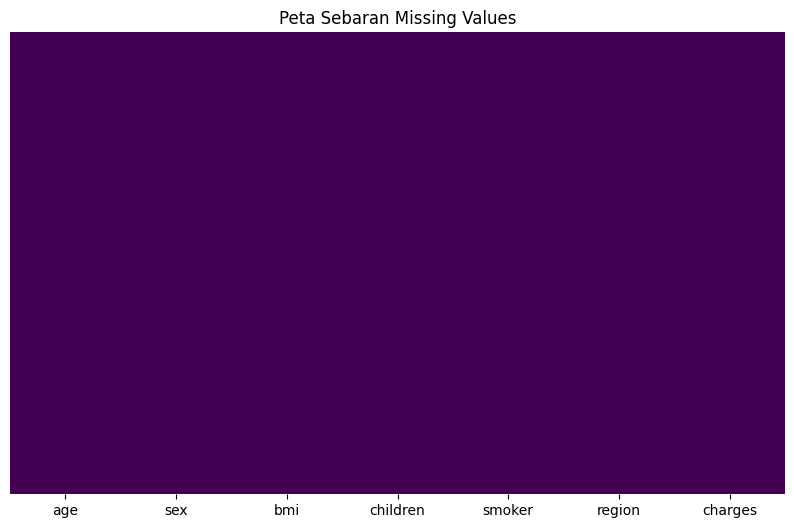


--- Pengecekan Data Duplikat ---
Jumlah baris duplikat identik: 1


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Pengecekan Missing Values ---")
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_table = pd.concat([missing_data, missing_percent], axis=1, keys=['Jumlah Missing', 'Persentase (%)'])
# Tampilkan hanya kolom yang memiliki missing value
display(missing_table[missing_table['Jumlah Missing'] > 0])

# Visualisasi Missing Values (Menggunakan Heatmap seaborn)
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Peta Sebaran Missing Values')
plt.show()

print("\n--- Pengecekan Data Duplikat ---")
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat identik: {jumlah_duplikat}")
# Jika ada, Anda bisa menampilkan contoh duplikatnya dengan mengaktifkan baris di bawah:
# if jumlah_duplikat > 0:
#     display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))

Langkah 8 Statistik Deskriptif

In [12]:
print("--- Statistik Deskriptif untuk Kolom Numerik ---")
display(df.describe())

print("\n--- Statistik Deskriptif untuk Kolom Kategori (Objek) ---")
display(df.describe(include='object'))

--- Statistik Deskriptif untuk Kolom Numerik ---


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010



--- Statistik Deskriptif untuk Kolom Kategori (Objek) ---


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


Langkah 9 Analisis Univariat

### Analisis Univariat untuk Kolom Numerik ###


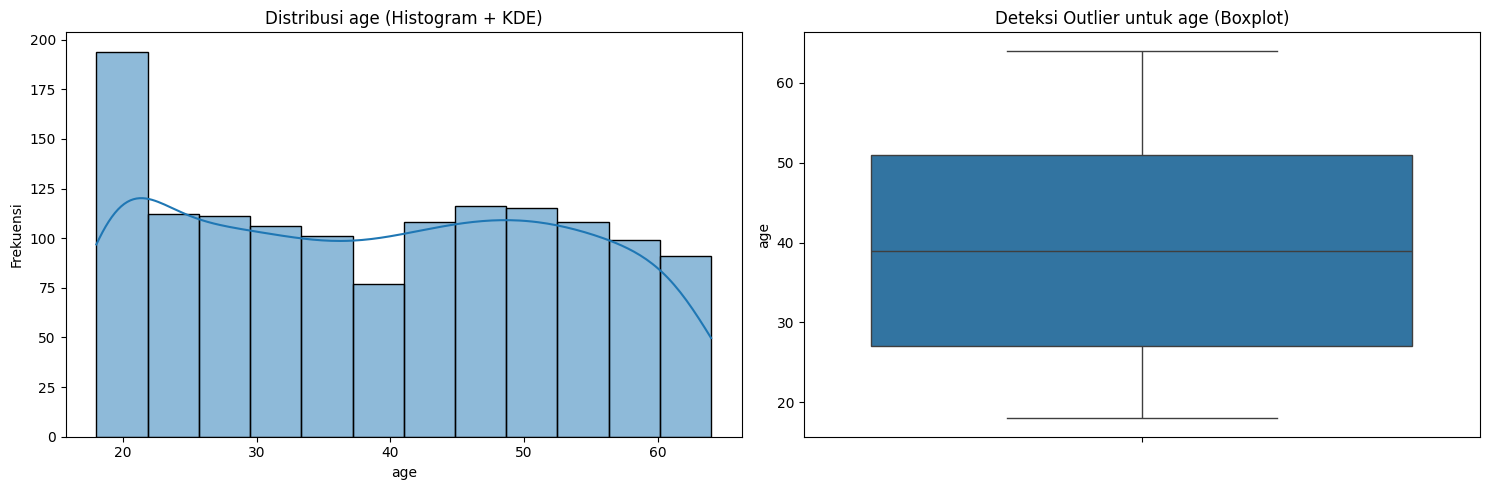

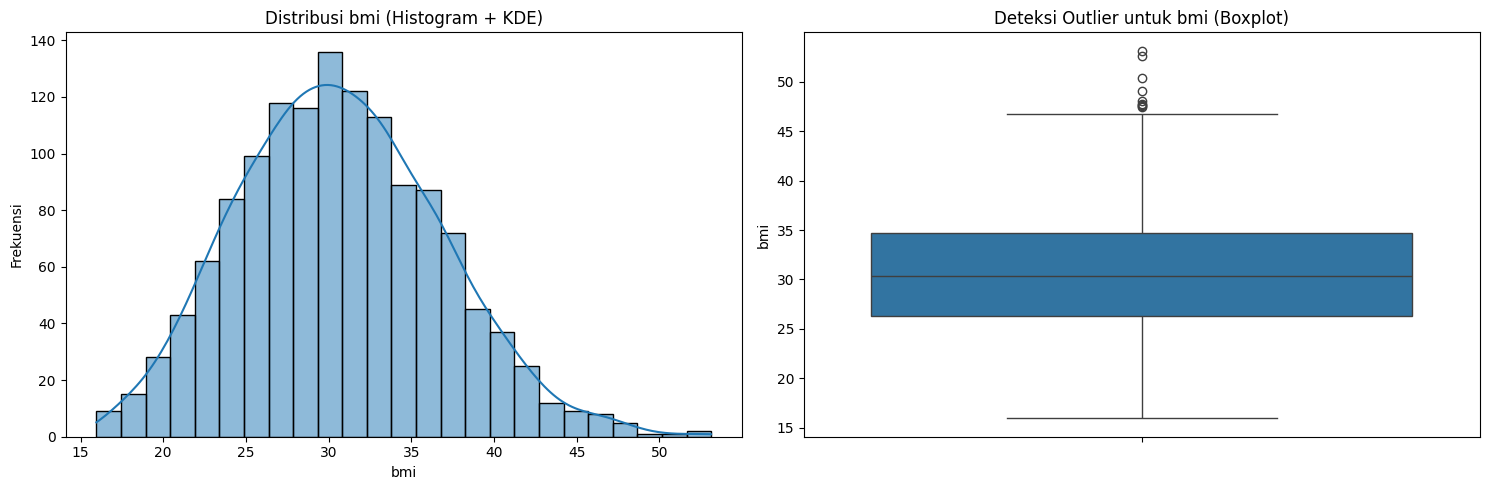

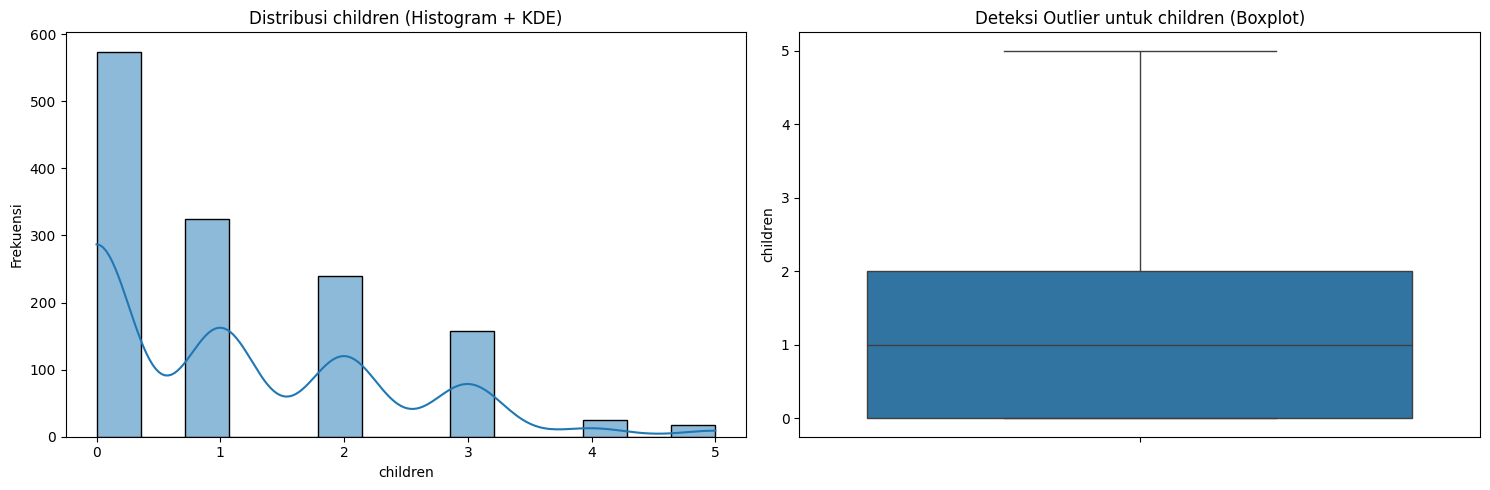

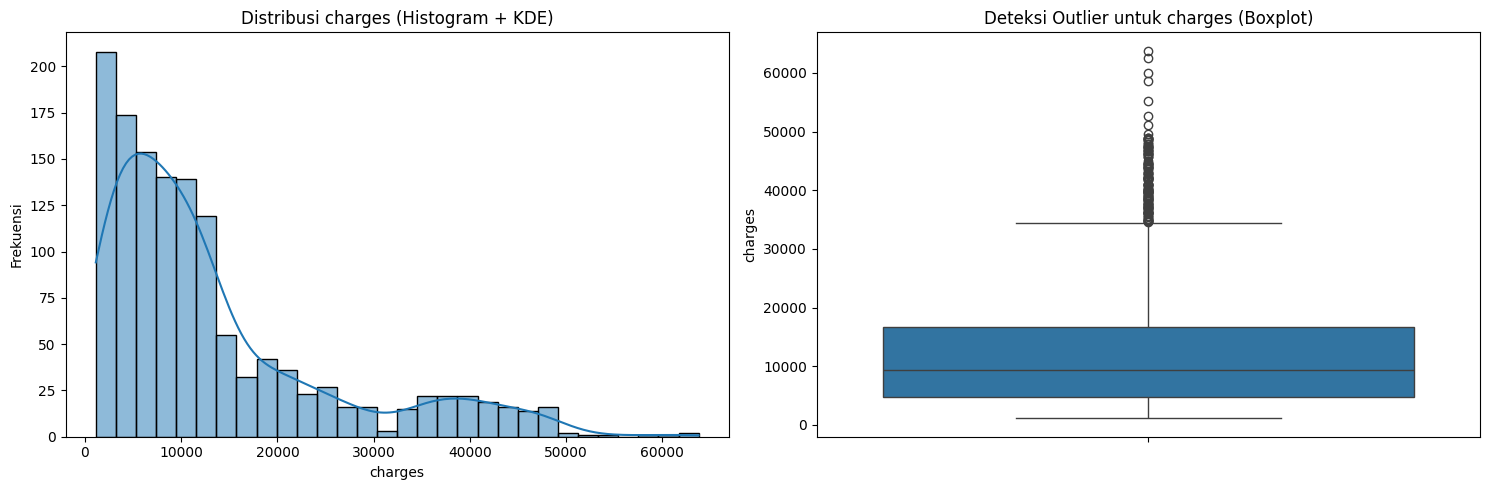


### Analisis Univariat untuk Kolom Kategorikal ###


/tmp/ipykernel_691/3295302882.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


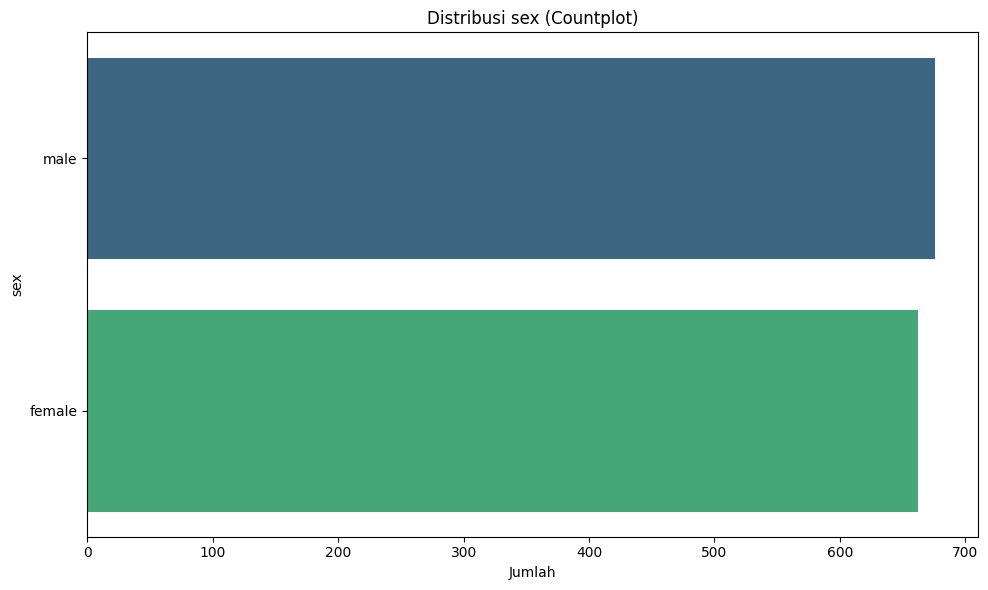

/tmp/ipykernel_691/3295302882.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


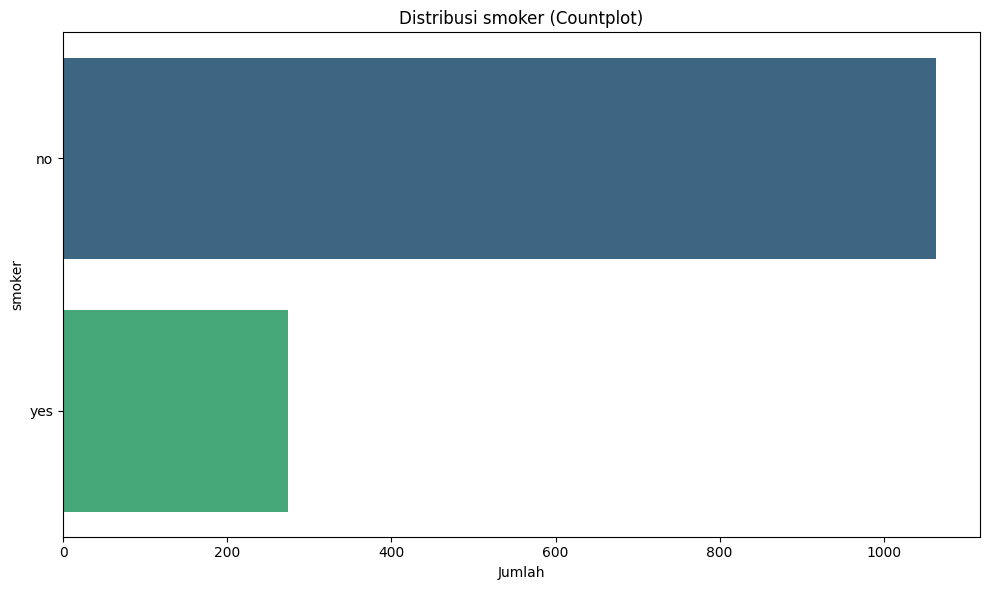

/tmp/ipykernel_691/3295302882.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


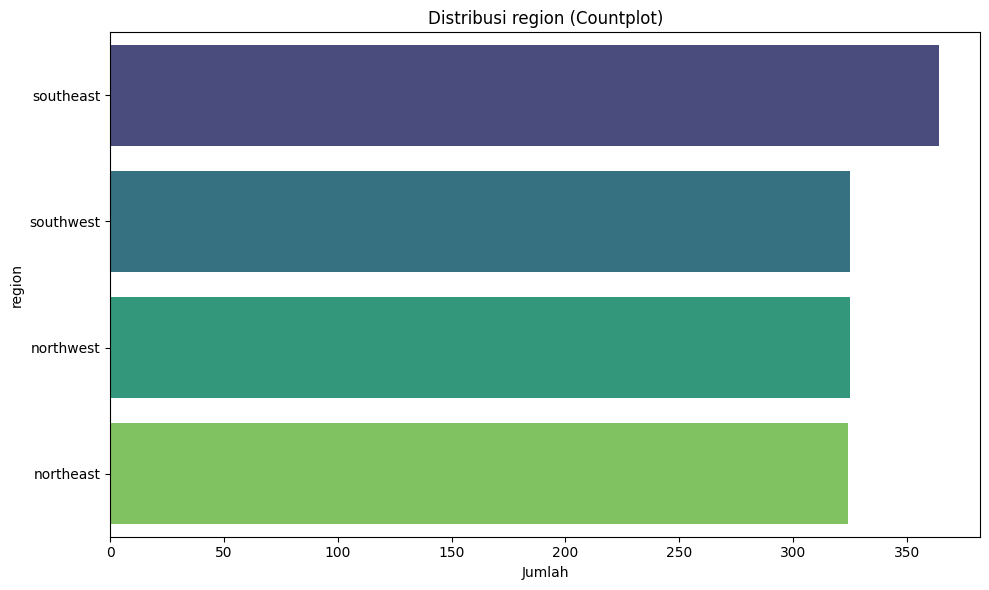

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Memisahkan kolom numerik dan kategorikal
kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
kolom_kategorikal = df.select_dtypes(include=['object']).columns.tolist()

print("### Analisis Univariat untuk Kolom Numerik ###")
for kolom in kolom_numerik:
    plt.figure(figsize=(15, 5))

    # Histplot dengan KDE
    plt.subplot(1, 2, 1) # 1 baris, 2 kolom, plot pertama
    sns.histplot(df[kolom], kde=True)
    plt.title(f'Distribusi {kolom} (Histogram + KDE)')
    plt.xlabel(kolom)
    plt.ylabel('Frekuensi')

    # Boxplot untuk Outliers
    plt.subplot(1, 2, 2) # 1 baris, 2 kolom, plot kedua
    sns.boxplot(y=df[kolom])
    plt.title(f'Deteksi Outlier untuk {kolom} (Boxplot)')
    plt.ylabel(kolom)

    plt.tight_layout()
    plt.show()

print("\n### Analisis Univariat untuk Kolom Kategorikal ###")
for kolom in kolom_kategorikal:
    plt.figure(figsize=(10, 6))
    # Countplot dengan pengurutan berdasarkan frekuensi
    sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')
    plt.title(f'Distribusi {kolom} (Countplot)')
    plt.xlabel('Jumlah')
    plt.ylabel(kolom)
    plt.tight_layout()
    plt.show()

Langkah 10 Analisis Bivariat & Multivariat

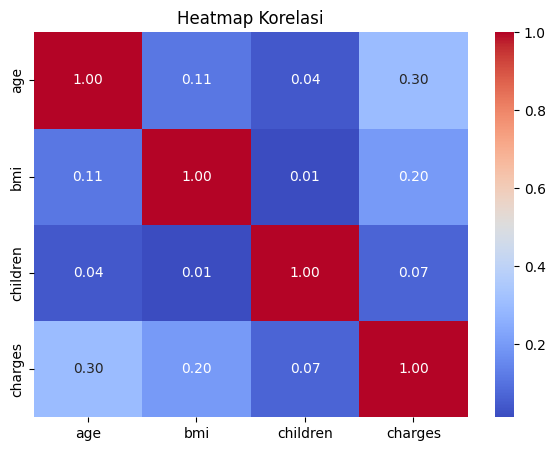

/tmp/ipykernel_691/2643261803.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="smoker", y="charges", palette="Set1")


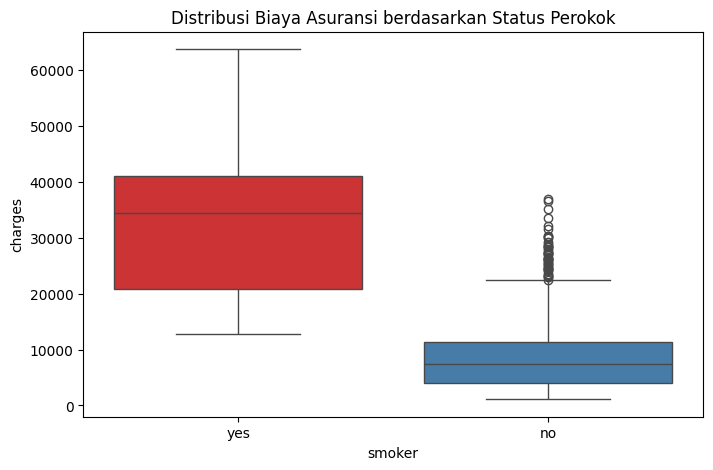

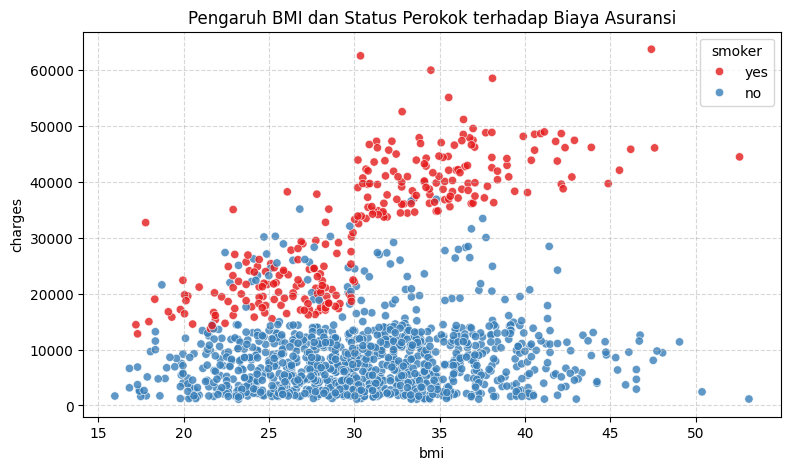

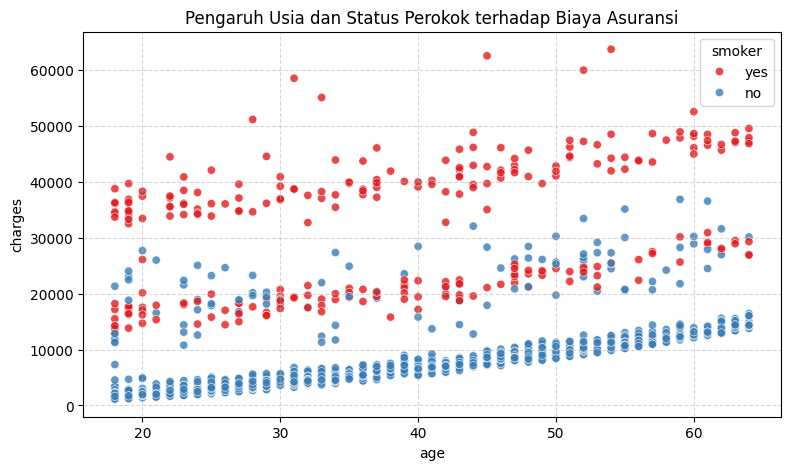

In [14]:
# A. Korelasi Numerik
plt.figure(figsize=(7, 5))
sns.heatmap(df[kolom_numerik].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi")
plt.show()

# B. Pengaruh Perokok terhadap Biaya (Smoker vs Charges)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="smoker", y="charges", palette="Set1")
plt.title("Distribusi Biaya Asuransi berdasarkan Status Perokok")
plt.show()

# C. Scatter Plot: BMI vs Charges (Interaksi Perokok)
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df, x="bmi", y="charges", hue="smoker", palette="Set1", alpha=0.8
)
plt.title("Pengaruh BMI dan Status Perokok terhadap Biaya Asuransi")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# D. Scatter Plot: Age vs Charges (Interaksi Perokok)
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df, x="age", y="charges", hue="smoker", palette="Set1", alpha=0.8
)
plt.title("Pengaruh Usia dan Status Perokok terhadap Biaya Asuransi")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

**B Preprocessing & Feature Engineering**

Langkah 1 Membuat Salinan Dataset

In [32]:
data = df.copy()

print("Ukuran data awal:", data.shape)

Ukuran data awal: (1337, 7)


Langkah 2 Penanganan Duplikat

In [33]:
# Hapus data duplikat (dataset insurance memiliki 1 baris duplikat)
df = df.drop_duplicates().reset_index(drop=True)
print("Ukuran setelah menghapus duplikat:", df.shape)

Ukuran setelah menghapus duplikat: (1337, 7)


Langkah 3 Memisahkan Fitur (X) dan Target (Y)

In [34]:
X = df.drop(columns=["charges"])  # Fitur
y = df["charges"]  # Target variable

Langkah 4 Encoding Variabel Kategorikal

In [35]:
# Binary Encoding (Map manual 0/1 untuk fitur 2 kategori)
X["sex"] = X["sex"].map({"female": 0, "male": 1})
X["smoker"] = X["smoker"].map({"no": 0, "yes": 1})

# One-Hot Encoding untuk variabel multi-kategori ('region')
X = pd.get_dummies(X, columns=["region"],  dtype=int)

print("\nFitur setelah Encoding:")
print(X.head())


Fitur setelah Encoding:
   age  sex     bmi  children  smoker  region_northeast  region_northwest  \
0   19    0  27.900         0       1                 0                 0   
1   18    1  33.770         1       0                 0                 0   
2   28    1  33.000         3       0                 0                 0   
3   33    1  22.705         0       0                 0                 1   
4   32    1  28.880         0       0                 0                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  


Langkah 5 Pemisahan Data Latih & Uji

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(
    f"\nJumlah data latih: {X_train.shape[0]}, Jumlah data uji:"
    f" {X_test.shape[0]}"
)


Jumlah data latih: 1069, Jumlah data uji: 268


Langkah 6 Feature Scaling

In [38]:
# Inisialisasi StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Inisialisasi daftar kolom numerik yang perlu diskalakan
kolom_numerik = ["age", "bmi", "children"]

# Fit & Transform hanya pada X_train, lalu Transform pada X_test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[kolom_numerik] = scaler.fit_transform(X_train[kolom_numerik])
X_test_scaled[kolom_numerik] = scaler.transform(X_test[kolom_numerik])

print("\n=== Preprocessing Selesai! ===")
print("Sampel Data Latih Terproses (X_train_scaled):")
print(X_train_scaled.head())


=== Preprocessing Selesai! ===
Sampel Data Latih Terproses (X_train_scaled):
           age  sex       bmi  children  smoker  region_northeast  \
1113 -1.157680    1 -0.996928 -0.907908       0                 1   
967  -1.300619    1 -0.792762  0.766904       0                 1   
598   0.914926    0  1.154664  0.766904       0                 0   
170   1.701087    1  1.806837 -0.907908       0                 0   
275   0.557580    0 -0.651417  0.766904       0                 1   

      region_northwest  region_southeast  region_southwest  
1113                 0                 0                 0  
967                  0                 0                 0  
598                  1                 0                 0  
170                  0                 1                 0  
275                  0                 0                 0  


**C Regresi Linear**

Langkah 1 Pelatihan Model Regresi Linear

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Inisialisasi model
model = LinearRegression()

# Latih model dengan data latih
model.fit(X_train_scaled, y_train)

# Prediksi biaya pada data uji
y_pred = model.predict(X_test_scaled)

Langkah 2 Evaluasi Model

In [41]:
import numpy as np
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== HASIL EVALUASI MODEL REGRESI LINEAR ===")
print(f"R-squared (R2) : {r2:.4f}")
print(f"MAE            : ${mae:.2f}")
print(f"RMSE           : ${rmse:.2f}")

=== HASIL EVALUASI MODEL REGRESI LINEAR ===
R-squared (R2) : 0.8069
MAE            : $4177.05
RMSE           : $5956.34


Langkah 3 Memeriksa Pengaruh Koefisien

In [42]:
koefisien = pd.DataFrame(
    {"Fitur": X.columns, "Koefisien": model.coef_}
).sort_values(by="Koefisien", ascending=False)

print("\n=== PENGARUH MASING-MASING FITUR ===")
print(koefisien.to_string(index=False))


=== PENGARUH MASING-MASING FITUR ===
           Fitur    Koefisien
          smoker 23077.764593
             age  3472.975553
             bmi  1927.828251
        children   636.501185
region_northeast   472.455206
region_northwest    80.693751
             sex  -101.542054
region_southwest  -186.684546
region_southeast  -366.464410


Langkah 4 Grafik Actual vs Predicted Plot

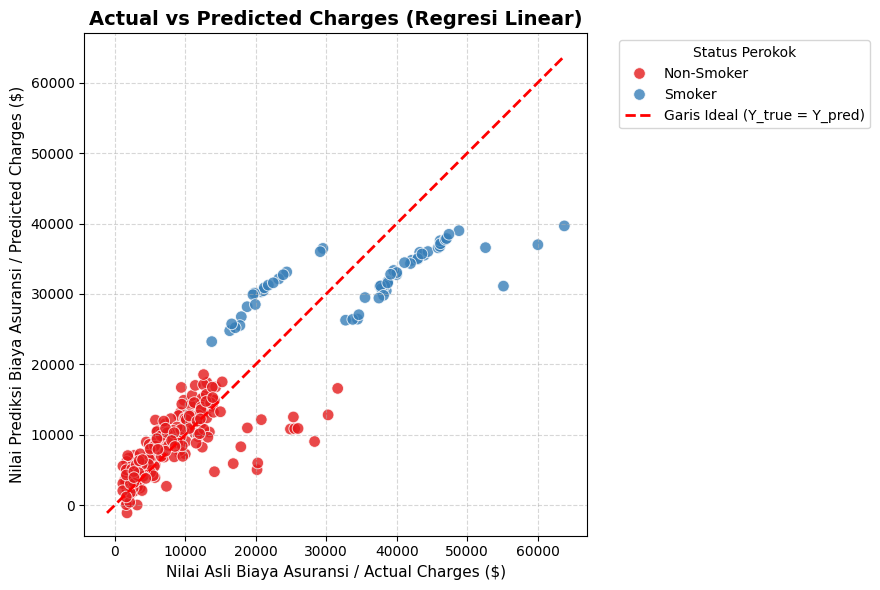

In [44]:
import seaborn as sns
plt.figure(figsize=(9, 6))

# Scatter plot membandingkan Y asli (y_test) dan Y hasil prediksi (y_pred)
sns.scatterplot(
    x=y_test,
    y=y_pred,
    hue=X_test["smoker"].map({0: "Non-Smoker", 1: "Smoker"}),
    palette="Set1",
    alpha=0.8,
    s=70,
)

# Garis diagonal merah sebagai acuan garis ideal (Prediksi Sempurna)
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Garis Ideal (Y_true = Y_pred)",
)

# Label dan Judul Visualisasi
plt.title(
    "Actual vs Predicted Charges (Regresi Linear)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Nilai Asli Biaya Asuransi / Actual Charges ($)", fontsize=11)
plt.ylabel("Nilai Prediksi Biaya Asuransi / Predicted Charges ($)", fontsize=11)
plt.legend(title="Status Perokok", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()